In [42]:
import os
import numpy as np
import time
from scipy import stats
from scipy.spatial import distance
import networkx as nx
from webweb import Web
from IPython.display import IFrame
import matplotlib.pyplot as plt
%matplotlib inline

I. File Manipulation and Utility Functions

II. Enrichment score variations: <br>
1. [Subramanian enrichment score with reduced data set](#1)
2. [Han enrichment score](#2)
3. [p value from KS test](#3)
4. [Euclidean distance](#4)

III. Association matrix:
1. [Association score](#5)
2. [Signature size analysis (TODO)](#6)
3. [Association matrix](#7)

# I. File Manipulation and Utility Functions

In [2]:
path_parent = os.path.dirname(os.path.dirname(os.path.abspath('pairwise_gsea_association_mtx.ipynb')))
rank_mtx_f = open(path_parent + ('/deseq/res/rank_matrix.txt'),'r')
rank_mtx_raw = rank_mtx_f.readlines()
rank_mtx_f.close()

rank_mtx_f_005 = open(path_parent + ('/deseq/res/rank_matrix_padj_cutoff_005.txt'),'r')
rank_mtx_raw_005 = rank_mtx_f_005.readlines()
rank_mtx_f_005.close()

rank_mtx_f_001 = open(path_parent + ('/deseq/res/rank_matrix_padj_cutoff_001.txt'),'r')
rank_mtx_raw_001 = rank_mtx_f_001.readlines()
rank_mtx_f_001.close()

virus_names = rank_mtx_raw[0].strip().split('\t')

In [3]:
#param: List[string]; raw rank matrix
#return: dict[string -> List[[string,int]];
def create_rank_dict(path):
    
    path_parent = os.path.dirname(os.path.dirname(os.path.abspath('pairwise_gsea_association_mtx.ipynb')))
    rank_mtx_f = open(path_parent + ('/deseq/res/rank_matrix.txt'),'r')
    rank_mtx_raw = rank_mtx_f.readlines()
    rank_mtx_f.close()
    
    virus_names = rank_mtx_raw[0].strip().split('\t')
    rank_dict = {}
    for name in virus_names:
        rank_dict[name] = []

    for line in rank_mtx_raw[1:]:
        line = line.strip().split('\t')
        for idx,name in enumerate(virus_names):
            rank_dict[name].append([line[0],int(line[idx+1])])

    #order each rank list by rank
    for name in virus_names:
        rank_dict[name] = sorted(rank_dict[name],key=lambda l:l[1])
        
    return rank_dict

In [4]:
rank_dict_all = create_rank_dict('/deseq/res/rank_matrix.txt')
rank_dict_005 = create_rank_dict('/deseq/res/rank_matrix_padj_cutoff_005.txt')
rank_dict_001 = create_rank_dict('/deseq/res/rank_matrix_padj_cutoff_001.txt')
rank_dict_0001 = create_rank_dict('rank_matrix_padj_cutoff_0001_rowVar.txt')

In [5]:
#param matrix: List[List[Double]] or np.ndarry(Double), ndim=2;
#pretty print matrix
def print_mtx(matrix):
    s = [[str("{:.2e}".format(e)) for e in row] for row in matrix]
    lens = [max(map(len, col)) for col in zip(*s)]
    fmt = '  '.join('{{:{}}}'.format(x) for x in lens)
    table = [fmt.format(*row) for row in s]
    print ('\n'.join(table))

In [6]:
#param mtx: np.ndarry(Double), ndim=2;
#draw heatmap from matrix
def heatmap(mtx,figsize=(8,6),title='',xlabel='',ylabel='',xticks=virus_names,yticks=virus_names):
    plt.figure(1,figsize=figsize)
    heatmap = plt.pcolor(mtx)
    plt.colorbar(heatmap)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(np.arange(len(xticks))+0.5,xticks)
    plt.yticks(np.arange(len(yticks))+0.5,yticks)

    plt.show()

# II. Enrichment Score Variations

<a id='1'></a>
### 1. Subramanian enrichment score

https://www.pathwaycommons.org/guide/primers/data_analysis/gsea/
![notation](sub_notation.png)
![sub_eq1](sub_eq1.png)
![sub_eq2_eq3](sub_eq2_eq3.png)
https://mathworld.wolfram.com/Supremum.html
![supremum](supremum.png)

In [7]:
#calculate enrichment score of signature gene set G of virus A in ranked list of genes L of virus B
#param rank_list: List([string,int]); list of tuples [gene, rank] ordered by rank 
#param G: List(string); list of signature genes of virus A
#param alpha: double; proportionality constant controls weight of rank
def subr_ES(sig_list_A,rank_list_B,alpha=1):
    n = len(rank_list_B) #number of total genes
    nk = len(sig_list_A) #number of genes in signature set
    L = [tup[0] for tup in rank_list_B] #ordered list of gene names
    s = [int(tup[1]) for tup in rank_list_B] #ordered list of gene ranks
    sig_list_A_names = [tup[0] for tup in sig_list_A]
    
    #note: range(x,y) = [x,y) and lists are zero-indexed
    
    def Fi_Gk(i):
        numerator = sum([abs(s[t])**alpha * int(L[t] in sig_list_A_names) for t in range(i)])
        denominator = sum([abs(s[t])**alpha * int(L[t] in sig_list_A_names) for t in range(n)])
        return numerator/denominator
        
    def Fi_not_Gk(i):
        numerator = sum([1*int(L[t] not in sig_list_A_names) for t in range(i)])
        denominator = n - nk
        return numerator/denominator
    
    return max([Fi_Gk(i) - Fi_not_Gk(i) for i in range(n)])

<a id='2'></a>
### 2. Han enrichment score

https://www.nature.com/articles/srep15820 <br>
This formula looks weird. It doesn't seem to be taking into account any of the ranks for the signature genes?

![notation](han_es.png)

ES = $top$ if |$top$| > |$bottom$|, otherwise $bottom$

In [8]:
#calculate enrichment score of signature gene set G of virus A in ranked list of genes L of virus B
#param rank_list_A: List([string,int]); list of tuples [gene, rank] ordered by rank
#param sig_list_B: List([string,int]); list of signature genes of virus
def han_ES(sig_list_A,rank_list_B):
    n = len(sig_list_A)
    m = len(rank_list_B)
    
    top_arr = []
    bot_arr = []
    
    for i in range(n):
        Ri = [gene for gene in rank_list_B if gene[0] == sig_list_A[i][0]][0]
#         print(Ri[0])
#         print(sig_list_A[i][0])
        top_arr.append(i/n - Ri[1]/m)
        bot_arr.append((i-1)/n - Ri[1]/m)
#         top_arr.append(i/n - rank_list_B[i][1]/m)
#         bot_arr.append((i-1)/n - rank_list_B[i][1]/m)
        
    top = max(top_arr)
    bot = min(bot_arr)
    
#     formatted_top_arr = [round(t,3) for t in top_arr]
#     formatted_bot_arr = [round(b,3) for b in bot_arr]
#     print(f'top_arr: {formatted_top_arr[:10]}')
#     print(f'bot_arr: {formatted_bot_arr[:10]}')
    
    if abs(top) > abs(bot):
        return top
    else:
        return bot

<a id='3'></a>
### 3. p Values from Kolmogorov-Smirnov Test

kstest documentation: <br>
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html <br>
video on KS test: <br>
https://www.youtube.com/watch?v=ZO2RmSkXK3c <br>

Is it plausible that the HVR of virus A was drawn from the same distribution as the HVR of virus B?

I don't think the KS test can be applied to different sets of genes without some major modifications, so to determine the "KS enrichment score" of virus A in B, I'll compare the entire rank list. I also order each list by gene name, not rank, so that the comparisons are being drawn between each gene. This will result in a symmetric matrix.
<br>
TODO: look into implications of one-sided vs. two-sided (current is two-sided)
-Shorter list?
-top 250 of HIV, match to DENV1

In [9]:
#calculate enrichment score of virus A in virus B
#compare ranks in A and B of signature genes of B
#param rank_list_A: List([string,int]); list of tuples [gene, rank] ordered by rank 
#param rank_list_B: List([string,int]); list of tuples [gene, rank] ordered by rank 
#param sig_size: int; 
def KS_ES(rank_list_A,rank_list_B):
    
    rank_list_A = sorted(rank_list_A,key=lambda l:l[0])
    rank_list_B = sorted(rank_list_B,key=lambda l:l[0])
    #print(rank_list_A[:10])
    
    ls_A = [ele[1] for ele in rank_list_A]
    ls_B = [ele[1] for ele in rank_list_B]
    (D, p) = stats.ks_2samp(ls_A, ls_B)
    #print(ls_A[:100])
    #print(ls_B[:100])
    #print(np.mean(np.array(ls_A) - np.array(ls_B)))
    return p

<a id='4'></a>
### 4. Euclidean Distance

Similarly to the KS test, this requires us to compare the entire lists, order each list by gene name, and results in a symmetric matrix.

In [10]:
#calculate enrichment score of signature gene set sig_genes of virus A in ranked list of genes L of virus B
#param rank_list: List([string,int]); list of tuples [gene, rank] ordered by rank 
#param sig_genes: List(string); list of signature genes of virus
def eucl_ES(rank_list_A,rank_list_B):
    #sort by gene name
    rank_list_A = sorted(rank_list_A,key=lambda l:l[0])
    rank_list_B = sorted(rank_list_B,key=lambda l:l[0])
    #create 1D list with ranks
    ls_A = [ele[1] for ele in rank_list_A]
    ls_B = [ele[1] for ele in rank_list_B]
    return distance.euclidean(ls_A, ls_B)

# III. Association Matrix

<a id='5'></a>
### 1. Association Score
https://www.nature.com/articles/srep15820
![eq4](eq4.png)

*NOTE:*
Since KS_ES and eucl_ES compare the entire lists, AS = ES for those tests

In [11]:
#calculate the association score between virus A and virus B
#param rank_list_A: List([string,int]); list of tuples [gene, rank] ordered by rank for virus A
#param rank_list_B: List([string,int]); list of tuples [gene, rank] ordered by rank for virus B
#param ES: function[List[string],List[string]->double]; enrichment score function
#param sig_size: int; signature set contains the top {sig_size} and bottom {sig_size} ranked genes, sig_size = nk/2
def association_score(rank_list_A, rank_list_B,ES,sig_size=250):
    
    #a. Subramanian ES
    if ES == subr_ES:
    
        upA = rank_list_A[:sig_size]
        downA = rank_list_A[-sig_size:]
        upB = rank_list_B[:sig_size]
        downB = rank_list_B[-sig_size:]

        return (subr_ES(rank_list_A,upB) + subr_ES(rank_list_B,upA) - subr_ES(rank_list_A,downB) - subr_ES(rank_list_B,downB))/4
    
    
    
    #b. Han ES
    if ES == han_ES:
        
        upA = rank_list_A[:sig_size]
        downA = rank_list_A[-sig_size:]
        upB = rank_list_B[:sig_size]
        downB = rank_list_B[-sig_size:]
        
        #print(f'upA: {upA}')
        #print(f'downA: {downA}')
        #print(f'upB: {upB}')
        #print(f'downB: {downB}')
        
        return (ES(upB,rank_list_A) + ES(upA,rank_list_B) - ES(downB,rank_list_A) - ES(downB,rank_list_A))/4
#         print('\nES upB in A')
#         one = ES(upB,rank_list_A)
#         print('\n ES upA in B')
#         two = ES(upA,rank_list_B)
#         print('\n ES downB in A')
#         three = ES(downB,rank_list_A)
#         print('\n ES downA in B')
#         four = ES(downA,rank_list_B)
#         return (one+two-three-four)/4
    
    
    #c. KS ES
    if ES == KS_ES:
        return KS_ES(rank_list_A,rank_list_B)
    
    #d. Euclidean ES
    if ES == eucl_ES:
        
        return eucl_ES(rank_list_A,rank_list_B)

<a id='6'></a>
### 2. Signature Size Analysis (TODO)

From Han et. al.: We selected the highest- and lowest-ranked 250 genes from each PRL as a pathogen signature. The GSEA-based PRL comparing method is a parameter-free algorithm, with the exception of signature size (recommended range, 15–500 per gene set, with lower size increasing randomness and large size decreasing specificity). We estimated the size parameter influence by sampling from 50 to 450 in intervals of 50. Pearson correlation coefficients of the association scores between 1,225 pairs of HTR relations indicated that the association scores obtained within this tested signature size range correlated with one another robustly.

<a id='7'></a>
### 3. Association Matrix

In [12]:
#param rank_dict:
#param ES: function[];
#param time: bool;
#param draw: bool;
def association_mtx(rank_dict,ES,print_time=False,draw=False):
    virus_names = list(rank_dict.keys())
    A = np.zeros(shape=(len(virus_names),len(virus_names))) #initialize the matrix
    
    t0 = time.time()
    
    for i in range(len(virus_names)):
        for j in range(i,len(virus_names)): #since the matrix is symmetric, don't calculate both A(i,j) and A(j,i)
            assoc_score = association_score(rank_dict[virus_names[i]], rank_dict[virus_names[j]],ES)
            #print(f'{virus_names[i]},{virus_names[j]}: Association score = {assoc_score}')
            A[i,j] = assoc_score
            A[j,i] = assoc_score
            
        if print_time: print(f'{virus_names[i]}: {round(time.time()-t0,2)}s')
            
    if draw: heatmap(A,title=ES.__name__)
    
    return A

<a id='8'></a>
#### 3a. Association Matrix Using Subramanian Enrichment Score

DENV1: 1614.58s
DENV2: 3049.38s
HSV1: 4402.36s
EBOLA: 5682.96s
HRV: 7438.73s
HIV: 8089.56s
RSV: 8584.14s
STAPH: 8987.57s
IAV: 9223.42s
HCMV: 9353.36s


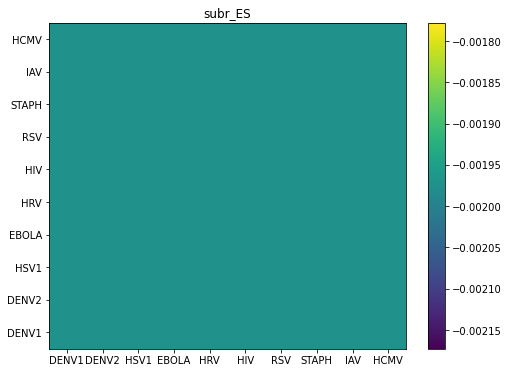

In [109]:
subr_mtx = association_mtx(rank_dict_0001,subr_ES,print_time=True,draw=True)

In [110]:
print_mtx(subr_mtx)

-1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03
-1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03
-1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03
-1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03
-1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03
-1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03
-1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03
-1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03
-1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03  -1.98e-03
-1.98e-03  -1.98e-0

<a id='9'></a>
#### 3b. Association Matrix Using Han Enrichment Score

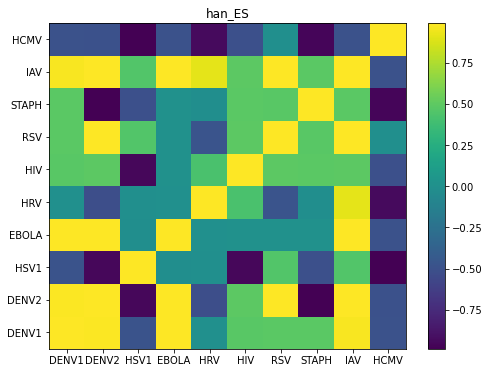

In [13]:
han_mtx = association_mtx(rank_dict_001,han_ES,draw=True)

<a id='10'></a>
#### 3c. Association Matrix Using KS Enrichment Score

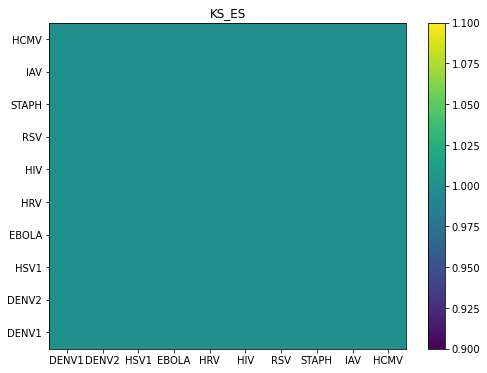

In [102]:
KS_mtx = association_mtx(rank_dict_001,KS_ES,draw=True)

In [94]:
print_mtx(KS_mtx)

1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00
1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00
1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00
1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00
1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00
1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00
1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00
1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00
1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00
1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00  1.00e+00


<a id='11'></a>
#### 3d. Association Matrix Using Euclidean Enrichment Score

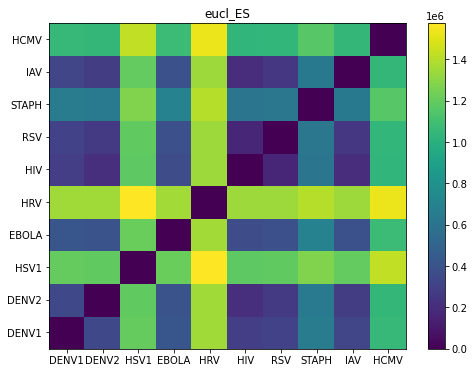

In [78]:
eucl_mtx = association_mtx(rank_dict_all,eucl_ES,draw=True)

In [86]:
print_mtx(eucl_mtx)

0.00e+00  3.59e+04  9.51e+04  4.43e+04  9.90e+04  3.32e+04  3.50e+04  5.67e+04  3.52e+04  8.63e+04
3.59e+04  0.00e+00  9.34e+04  4.24e+04  9.88e+04  2.01e+04  2.39e+04  5.36e+04  2.45e+04  8.43e+04
9.51e+04  9.34e+04  0.00e+00  9.67e+04  1.08e+05  9.33e+04  9.40e+04  9.82e+04  9.41e+04  1.03e+05
4.43e+04  4.24e+04  9.67e+04  0.00e+00  9.82e+04  3.97e+04  4.18e+04  6.06e+04  3.99e+04  8.70e+04
9.90e+04  9.88e+04  1.08e+05  9.82e+04  0.00e+00  9.82e+04  9.84e+04  1.01e+05  9.77e+04  1.06e+05
3.32e+04  2.01e+04  9.33e+04  3.97e+04  9.82e+04  0.00e+00  1.80e+04  5.13e+04  1.90e+04  8.32e+04
3.50e+04  2.39e+04  9.40e+04  4.18e+04  9.84e+04  1.80e+04  0.00e+00  5.18e+04  2.34e+04  8.39e+04
5.67e+04  5.36e+04  9.82e+04  6.06e+04  1.01e+05  5.13e+04  5.18e+04  0.00e+00  5.24e+04  9.09e+04
3.52e+04  2.45e+04  9.41e+04  3.99e+04  9.77e+04  1.90e+04  2.34e+04  5.24e+04  0.00e+00  8.43e+04
8.63e+04  8.43e+04  1.03e+05  8.70e+04  1.06e+05  8.32e+04  8.39e+04  9.09e+04  8.43e+04  0.00e+00
